In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
  

In [3]:
df = pd.read_csv("../data/Nassau Candy Distributor.csv")

print("Shape:", df.shape)
df.head()

Shape: (10194, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

In [5]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [6]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format= '%d-%m-%Y')
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format= '%d-%m-%Y')

df["Lead Time"] = (df["Ship Date"] - df["Order Date"]).dt.days

df["Lead Time"].describe()

count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead Time, dtype: float64

In [7]:
df.groupby("Ship Mode")["Lead Time"].describe()

,count,mean,std,min,25%,50%,75%,max
Ship Mode,,,,,,,,
First Class,1548.0,1338.275840,265.632140,905.0,1270.0,1272.0,1637.0,1638.0
Same Day,547.0,1333.442413,253.813374,904.0,1269.0,1269.0,1635.0,1636.0
Second Class,1979.0,1323.845376,261.813569,906.0,1271.0,1273.0,1637.0,1640.0
Standard Class,6120.0,1314.334641,262.400116,908.0,1273.0,1274.0,1639.0,1642.0


In [8]:
df["Order Year"] = df["Order Date"].dt.year
df.groupby("Order Year")["Lead Time"].describe()

,count,mean,std,min,25%,50%,75%,max
Order Year,,,,,,,,
2024,4181.0,1094.018417,182.501417,904.0,908.0,1269.0,1273.0,1277.0
2025,6013.0,1478.558290,181.553830,1269.0,1273.0,1637.0,1639.0,1642.0


In [9]:
factories = pd.DataFrame({
    "Factory": ["Lot's O' Nuts", "Wicked Choccy's", "Sugar Shack", "Secret Factory", "The Other Factory"],
    "Factory Lat": [32.881893, 32.076176, 48.119140, 41.446333, 35.117500],
    "Factory Lon": [-111.768036, -81.088371, -96.181150, -90.565487, -89.971107]
})


product_factory = pd.DataFrame({
    "Product Name": [
        "Wonka Bar - Nutty Crunch Surprise", "Wonka Bar - Fudge Mallows", "Wonka Bar -Scrumdiddlyumptious",
        "Wonka Bar - Milk Chocolate", "Wonka Bar - Triple Dazzle Caramel",
        "Laffy Taffy", "SweeTARTS", "Nerds", "Fun Dip", "Fizzy Lifting Drinks",
        "Everlasting Gobstopper", "Hair Toffee", "Lickable Wallpaper", "Wonka Gum", "Kazookles"
    ],
    "Origin Factory": [
        "Lot's O' Nuts", "Lot's O' Nuts", "Lot's O' Nuts",
        "Wicked Choccy's", "Wicked Choccy's",
        "Sugar Shack", "Sugar Shack", "Sugar Shack", "Sugar Shack", "Sugar Shack",
        "Secret Factory", "The Other Factory", "Secret Factory", "Secret Factory", "The Other Factory"
    ]
})


df = df.merge(product_factory, on= "Product Name", how= "left")

print(df["Origin Factory"].isnull().sum(), "unmapped rows")
df[df["Origin Factory"].isnull()]["Product Name"].unique()

0 unmapped rows


<ArrowStringArray>
[]
Length: 0, dtype: str

In [10]:
unique_locations = df[["City", "State/Province", "Country/Region"]].drop_duplicates()
print("Unique locations to geocode:", len(unique_locations))
unique_locations.head()

Unique locations to geocode: 616


,City,State/Province,Country/Region
0,Houston,Texas,United States
1,Naperville,Illinois,United States
4,Philadelphia,Pennsylvania,United States
5,Henderson,Kentucky,United States
7,Athens,Georgia,United States


In [11]:
# pip install geopy

In [12]:
'''
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

geolocator = Nominatim(user_agent="nassau_candy_project", timeout=10)

geocode = RateLimiter(geolocator.geocode, min_delay_seconds= 1, max_retries= 3, error_wait_seconds= 2)

def get_coordinates(row):
    query = "{}, {}, {}".format(row["City"], row["State/Province"], row["Country/Region"])
    location = geocode(query)
    if location:
        return pd.Series([location.latitude, location.longitude])
    else:
        return pd.Series([None, None])

unique_locations[["Customer Lat", "Customer Lon"]] = unique_locations.apply(get_coordinates, axis=1)
print(unique_locations["Customer Lat"].isnull().sum(), "locations failed to geocode")

'''

'\nfrom geopy.geocoders import Nominatim\nfrom geopy.extra.rate_limiter import RateLimiter\n\ngeolocator = Nominatim(user_agent="nassau_candy_project", timeout=10)\n\ngeocode = RateLimiter(geolocator.geocode, min_delay_seconds= 1, max_retries= 3, error_wait_seconds= 2)\n\ndef get_coordinates(row):\n    query = "{}, {}, {}".format(row["City"], row["State/Province"], row["Country/Region"])\n    location = geocode(query)\n    if location:\n        return pd.Series([location.latitude, location.longitude])\n    else:\n        return pd.Series([None, None])\n\nunique_locations[["Customer Lat", "Customer Lon"]] = unique_locations.apply(get_coordinates, axis=1)\nprint(unique_locations["Customer Lat"].isnull().sum(), "locations failed to geocode")\n\n'

In [13]:
# unique_locations.to_csv("../data/geocoded_locations.csv", index= False)

In [14]:
unique_locations = pd.read_csv("../data/geocoded_locations.csv")
print(unique_locations.shape)
unique_locations.head()

(616, 5)


,City,State/Province,Country/Region,Customer Lat,Customer Lon
0,Houston,Texas,United States,29.758938,-95.367697
1,Naperville,Illinois,United States,41.772870,-88.147928
2,Philadelphia,Pennsylvania,United States,39.952724,-75.163526
3,Henderson,Kentucky,United States,37.767210,-87.557374
4,Athens,Georgia,United States,33.959768,-83.376398


In [15]:
df = df.merge(unique_locations, on= ["City", "State/Province", "Country/Region"], how= "left")

df = df.merge(factories, left_on= "Origin Factory", right_on= "Factory", how= "left")

print(df[["Customer Lat", "Customer Lon", "Factory Lat", "Factory Lon"]].isnull().sum())

Customer Lat    0
Customer Lon    0
Factory Lat     0
Factory Lon     0
dtype: int64


In [16]:
def haversine_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    r = 6371
    return c * r

df["Distance (km)"] = haversine_distance(
    df["Factory Lat"], df["Factory Lon"], df["Customer Lat"], df["Customer Lon"]
)

df["Distance (km)"].describe()

count    10194.000000
mean      2007.542429
std       1104.345900
min          7.992532
25%       1107.579150
50%       1723.663283
75%       3163.624575
max       5138.315780
Name: Distance (km), dtype: float64

In [17]:
base_days = {
    "Same Day": 0,
    "First Class": 1,
    "Second Class": 2,
    "Standard Class": 3
}

df["Base Days"] = df["Ship Mode"].map(base_days)

df["Distance Days"] = df["Distance (km)"]/800

np.random.seed(42)
df["Noise"] = np.random.normal(loc= 0, scale= 0.5, size= len(df))

df["Synthetic Lead Time"] = np.ceil(df["Base Days"] + df["Distance Days"] + df["Noise"]).clip(lower= 1)
df["Synthetic Lead Time"].describe()

count    10194.000000
mean         5.351089
std          1.755720
min          1.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: Synthetic Lead Time, dtype: float64

In [19]:
df.groupby("Ship Mode")["Synthetic Lead Time"].describe()

,count,mean,std,min,25%,50%,75%,max
Ship Mode,,,,,,,,
First Class,1548.0,4.014858,1.519675,1.0,3.0,4.0,5.0,7.0
Same Day,547.0,3.005484,1.476919,1.0,2.0,3.0,4.0,6.0
Second Class,1979.0,5.018696,1.473100,1.0,4.0,5.0,6.0,9.0
Standard Class,6120.0,6.006209,1.498802,2.0,5.0,6.0,7.0,10.0


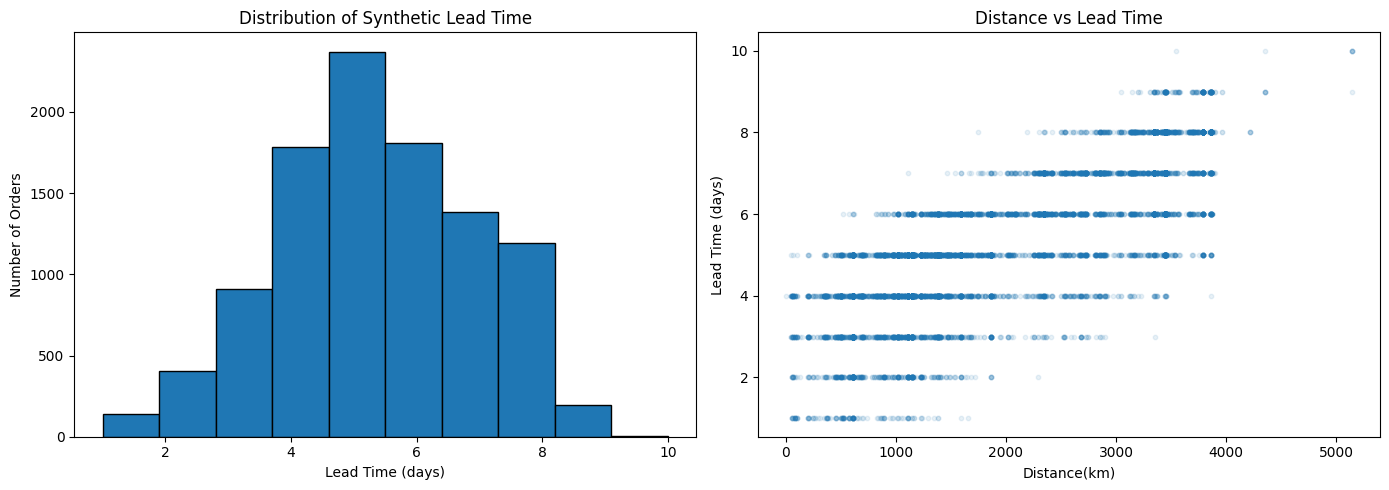

In [20]:
fig, axes = plt.subplots(1, 2, figsize= (14,5))

axes[0].hist(df["Synthetic Lead Time"], bins = 10, edgecolor = "black")
axes[0].set_title("Distribution of Synthetic Lead Time")
axes[0].set_xlabel("Lead Time (days)")
axes[0].set_ylabel("Number of Orders")

axes[1].scatter(df["Distance (km)"], df["Synthetic Lead Time"], alpha= 0.1, s =10)
axes[1].set_title("Distance vs Lead Time")
axes[1].set_xlabel("Distance(km)")
axes[1].set_ylabel("Lead Time (days)")

plt.tight_layout()
plt.show()

In [21]:
factory_summary = df.groupby("Origin Factory").agg(
    Avg_Lead_Time = ("Synthetic Lead Time", "mean"),
    Avg_Distance = ("Distance (km)", "mean"),
    Order_Count = ("Order ID", "count"),
    Avg_Gross_Profit = ("Gross Profit", "mean")
).sort_values("Avg_Lead_Time", ascending=False)

factory_summary

,Avg_Lead_Time,Avg_Distance,Order_Count,Avg_Gross_Profit
Origin Factory,,,,
Lot's O' Nuts,5.519852,2143.929972,5692,9.271091
Sugar Shack,5.303030,1796.858627,33,3.673636
Wicked Choccy's,5.181358,1860.959404,4152,8.683422
The Other Factory,4.700000,1641.620707,100,1.522500
Secret Factory,4.479263,1435.374518,217,20.021659


In [22]:
division_summary = df.groupby("Division").agg(
    Order_Count = ("Order ID", "count"),
    Avg_Lead_Time = ("Synthetic Lead Time", "mean"),
    Avg_Gross_Profit = ("Gross Profit", "mean"),
    Total_Gross_Profit = ("Gross Profit", "sum")
).sort_values("Order_Count", ascending=False)

division_summary

,Order_Count,Avg_Lead_Time,Avg_Gross_Profit,Total_Gross_Profit
Division,,,,
Chocolate,9844,5.377082,9.023224,88824.62
Other,310,4.551613,13.978871,4333.45
Sugar,40,5.150000,7.118250,284.73


In [23]:
region_summary = df.groupby("Region").agg(
    Order_Count = ("Order ID", "count"),
    Avg_Lead_Time = ("Synthetic Lead Time", "mean"),
    Avg_Distance = ("Distance (km)", "mean"),
    Avg_Gross_Profit = ("Gross Profit", "mean")
).sort_values("Avg_Lead_Time", ascending=False)

region_summary

,Order_Count,Avg_Lead_Time,Avg_Distance,Avg_Gross_Profit
Region,,,,
Atlantic,2986,5.793034,2356.900288,9.033389
Pacific,3253,5.347679,2040.061990,9.371638
Gulf,1620,5.059877,1778.717337,9.074488
Interior,2335,4.992719,1674.235342,9.114557


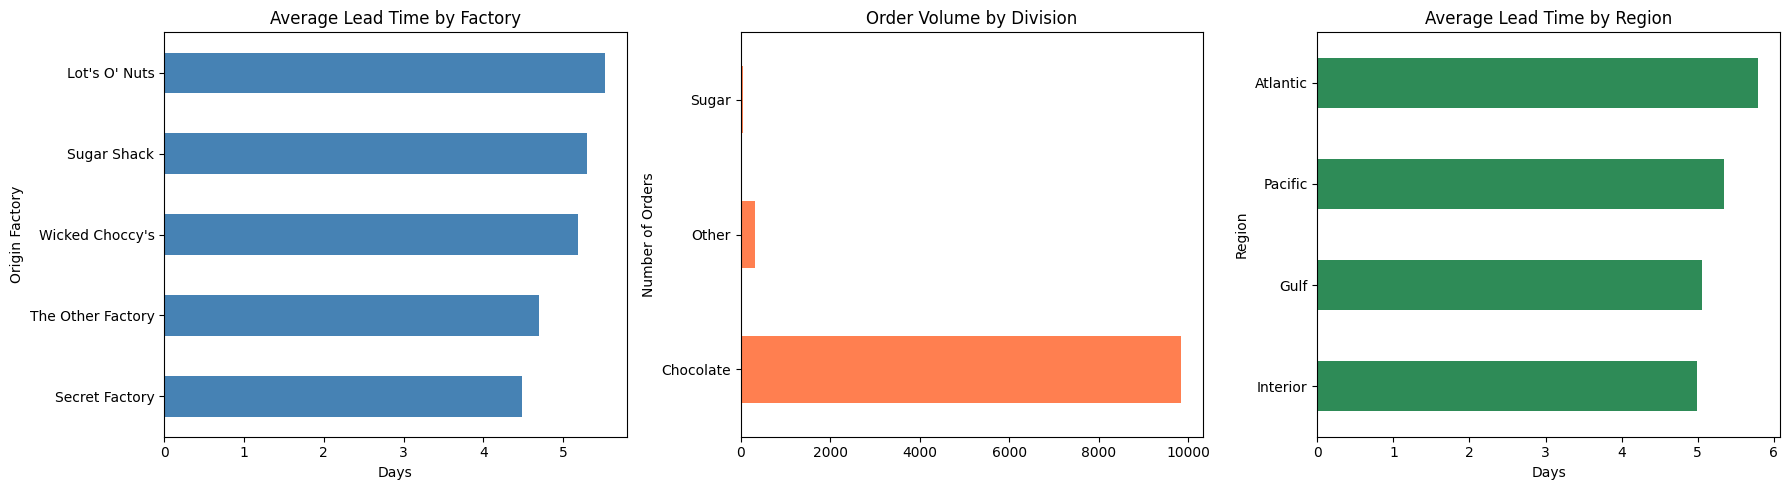

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

factory_summary["Avg_Lead_Time"].sort_values().plot(kind="barh", ax= axes[0], color= "steelblue")
axes[0].set_title("Average Lead Time by Factory")
axes[0].set_xlabel("Days")

division_summary["Order_Count"].plot(kind= "barh", ax= axes[1], color= "coral")
axes[1].set_title("Order Volume by Division")
axes[1].set_ylabel("Number of Orders")
axes[1].tick_params(axis= "x", rotation=0)

region_summary["Avg_Lead_Time"].sort_values().plot(kind= "barh", ax= axes[2], color= "seagreen")
axes[2].set_title("Average Lead Time by Region")
axes[2].set_xlabel("Days")

plt.tight_layout()
plt.show()


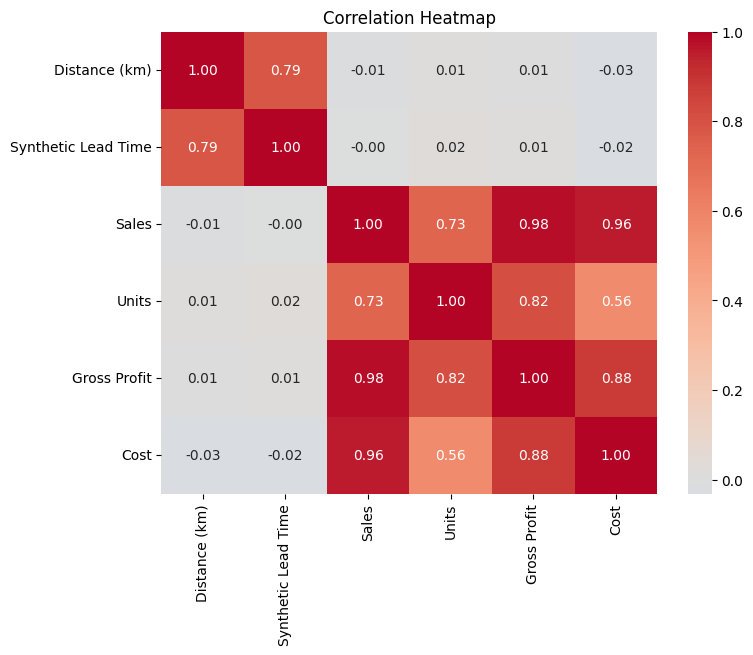

In [25]:
numeric_cols = ["Distance (km)", "Synthetic Lead Time", "Sales", "Units", "Gross Profit","Cost"]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot= True,cmap= "coolwarm", center= 0, fmt= ".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
'''
df.to_csv("../data/processed_data.csv", index= False)
print("Saved:", df.shape)
'''

Saved: (10194, 31)
